# K-means Clustering

This is an unsupervised learning algorithm, since we start with entirely unlabeled data. The choice of $k$ is a tricky one, and is a hyperparameter we choose carefully.

The algorithm:
1. Initialization: pick k random points to serve as centroids.
2. Repeat until convergence:
   1. Assignment: assign each datum to its nearest centroid.
   2. Update: update each centroid to be the mean of the assigned points.

The plan:
1. Synthesize data into three clear clusters
2. Implement k-means algorithm
3. Visualize the iterations
4. Explore the effect of k
5. Show effect of bad initialization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

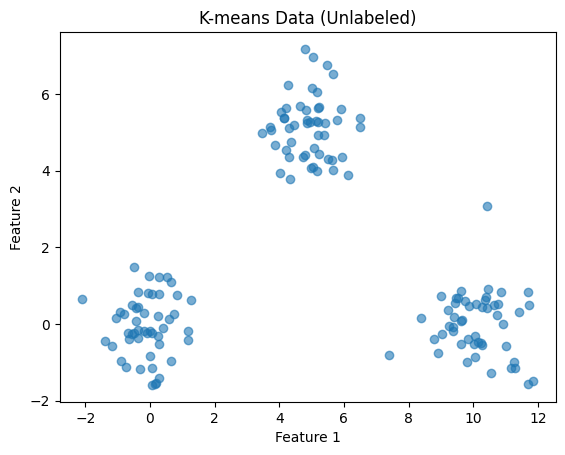

In [ ]:
# Generate 3 clusters
# Cluster 1: centered at [0, 0]
# Cluster 2: centered at [5, 5]
# Cluster 3: centered at [10, 0]
# Each cluster: 50 points, std=0.8, shape (50, 2)

cluster1 = np.random.randn(50, 2) * 0.8
cluster2 = np.random.randn(50, 2) * 0.8 + [5, 5] # use broadcasting
cluster3 = np.random.randn(50, 2) * 0.8 + [10, 0] # use broadcasting

# center_cluster_3 = np.vstack([np.ones(shape=(50,)) * 10, np.zeros(shape=(50,))]) # creates a vector of shape (2, 50).
# cluster3 = np.random.randn(50, 2) * 0.8 + center_cluster_3

X = np.vstack([cluster1, cluster2, cluster3]) # shape (150, 2)

# Plot
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title('K-means Data (Unlabeled)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
# Implement K-means
def initialize_centroids(X, k):
    """
    Randomly initialize k centroids by selecting k random points from X
    X: shape (n, 2)
    k: number of clusters
    returns: shape (k, 2)
    """
    # We want exactly k indices without replacement in the range of (0, X.shape[0])
    indices = np.random.choice(X.shape[0], size=k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    """
    Assign each point to nearest centroid
    X: shape (n, 2)
    centroids: shape (k, 2)
    returns: array of shape (n,) with cluster assignments (0 to k-1)
    """
    # Compute distance to all K centroids
    # Assign to the centroid that is the closest

    # X[:, np.newaxis, :] # shape (n, 1, 2)
    # centroids[np.newaxis, :, :] # shape (1, k, 2)
    # broadcasting # shape (n, k, 2)
    # taking sum over axis=2 results in shape (n, k)
    # taking argmin over axis=1 results in shape (n,)

    distances = np.sqrt(((X[:, np.newaxis, :] - centroids[np.newaxis, :, :])**2).sum(axis=2)) # shape (n, k)
    return np.argmin(distances, axis=1) # shape (n,)
    
    
def update_centroids(X, assignments, k):
    """
    Recompute centroids as mean of assigned points
    X: shape (n, 2)
    assignments: shape (n,) - cluster assignment for each point
    k: number of clusters
    returns: shape (k, 2) - new centroid positions
    """
    return np.array([X[assignments == i].mean(axis=0) for i in range(k)])

def compute_inertia(X, centroids, assignments, k):
    """
    Compute within-cluster sum of squares
    X: shape (n, 2)
    centroids: shape (k, 2)
    assignments: shape (n,) - cluster assignments
    k: number of clusters
    returns: scalar - inertia across all clusters
    """
    # For each point, compute squared distance to its assigned centroid
    # Sum all of them
    assigned_centroids = centroids[assignments] # shape (n, 2). fancy indexing. for each value in assignments, numpy grabs that row from centroids.
    return ((X - assigned_centroids)**2).sum() # .sum() sums over everything, so returns a scalar

In [ ]:
# Main loop for the k-means algorithm
def kmeans(X, k, max_iters=100, epsilon=None):
    """
    Run k-means clustering
    Returns: (final_centroids, final_assignments, inertia_history)
    """
    # Initialize
    centroids = initialize_centroids(X, k)
    inertia_history = []

    # Main iteration
    for iteration in range(max_iters):
        # Assignment step
        assignments = assign_clusters(X, centroids)
        
        # Add to history
        inertia_history.append(compute_inertia(X, assignments, centroids, k))

        # Update step
        new_centroids = update_centroids(X, assignments, k)

        # Check for convergence:
        centroids_converged = np.allclose(centroids, new_centroids)

        inertia_converged = False

        if epsilon:
            if len(inertia_history) > 1:
                relative_change = abs(inertia_history[-1] - inertia_history[-2]) / inertia_history[-2]
                inertia_converged = relative_change < epsilon

        if centroids_converged or inertia_converged:
            print(f"Converged at iteration {iteration}")
            break

        centroids = new_centroids

    return centroids, assignments, inertia_history

Converged at iteration 2


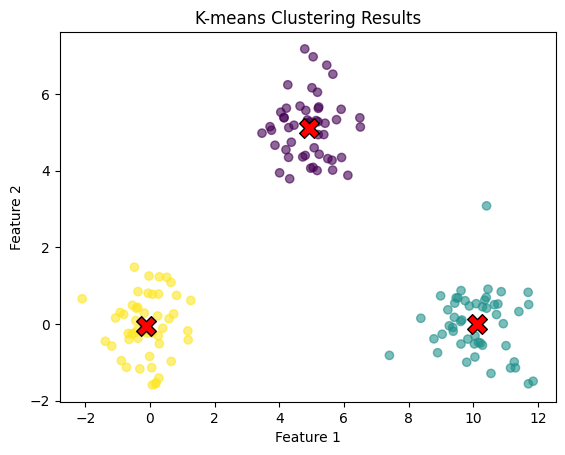

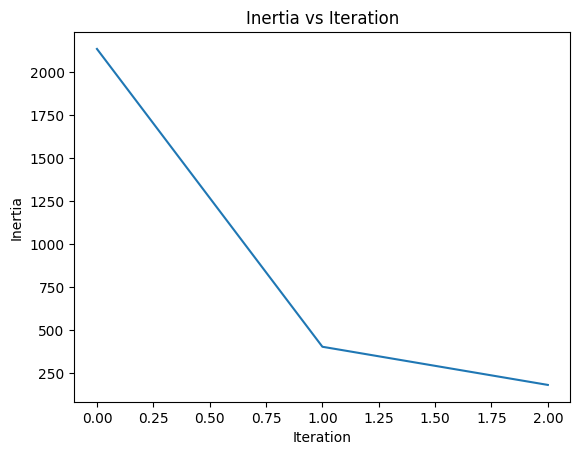

In [ ]:
# Run it!
np.random.seed(1322)
centroids, assignments, inertia_history = kmeans(X, k=3, max_iters=100)

# Plot results
plt.scatter(X[:, 0], X[:, 1], c=assignments, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black')
plt.title('K-means Clustering Results')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Plot inertia over iterations
plt.plot(inertia_history)
plt.xlabel('Iteration')
plt.ylabel('Inertia')
plt.title('Inertia vs Iteration')
plt.show()

Converged at iteration 1
Converged at iteration 1
Converged at iteration 1
Converged at iteration 8
Converged at iteration 10
Converged at iteration 10
Converged at iteration 6
Converged at iteration 6
Converged at iteration 7


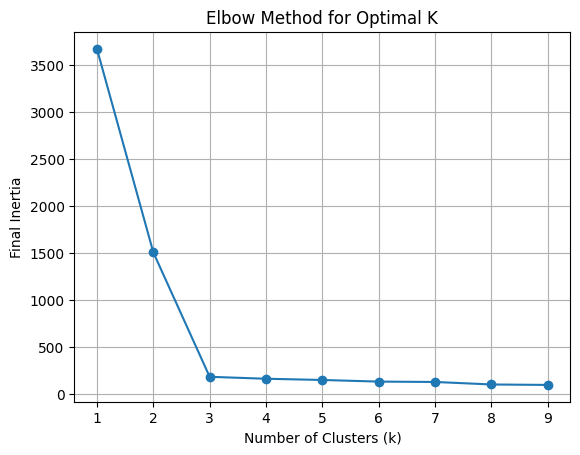

In [ ]:
# How to choose the correct k?
k_values = range(1, 10)
inertias = []

for k in k_values:
    np.random.seed(42)  # Same seed for fair comparison
    centroids, assignments, inertia_history = kmeans(X, k=k, max_iters=100)
    inertias.append(inertia_history[-1])

plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Final Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

With the elbow method, choose an optimal k by looking at where the inertia is minimized but does not suffer from diminishing returns. In our case, it's clear that we should choose k = 3.

Converged at iteration 10


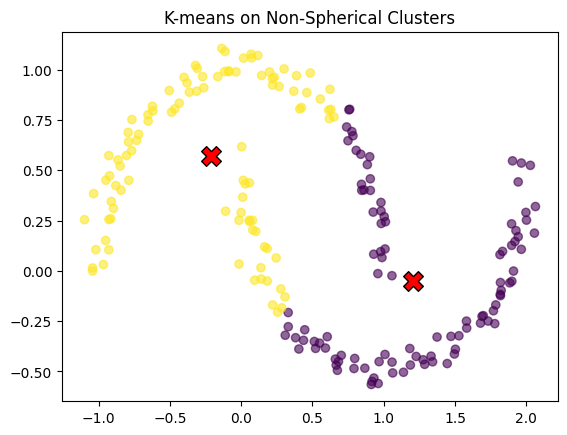

In [ ]:
# Let's explore k-means limitations.
# One huge assumption is that the clusters are spherical and of similar size.
# Let's see what happens when this assumption is violated.

# Create two moons (non-convex clusters)
from sklearn.datasets import make_moons

X_moons, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

# Try k-means on this
np.random.seed(42)
centroids, assignments, _ = kmeans(X_moons, k=2, max_iters=100)

plt.scatter(X_moons[:, 0], X_moons[:, 1], c=assignments, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black')
plt.title('K-means on Non-Spherical Clusters')
plt.show()